# Fuente de datos

Los proyectos de **Mantenimiento Predictivo** integran información proveniente de diferentes fuentes para comprender el estado operativo de los equipos y anticipar posibles fallas antes de que estas ocurran.

Las principales fuentes de información utilizadas en este tipo de soluciones son:

- **Características de las máquinas:** Información propia de cada equipo, como el modelo, fabricante, ubicación, fecha de instalación o antigüedad.

- **Datos de telemetría:** Mediciones capturadas por sensores durante la operación de las máquinas, como voltaje, velocidad de rotación, presión, vibración, temperatura o velocidad de operación.

- **Historial de mantenimiento:** Registro de las actividades de mantenimiento realizadas, incluyendo reparaciones, reemplazo de componentes, inspecciones y registros de servicio.

- **Historial de fallas:** Registro de las fallas ocurridas en los equipos o en componentes específicos.

En algunos casos, el historial de fallas puede encontrarse incluido dentro del historial de mantenimiento, por ejemplo mediante códigos de error, órdenes de reparación o registros de reemplazo de componentes. Cuando esto ocurre, es posible identificar las fallas a partir de dichos registros.

Dependiendo del sector industrial, pueden existir otras fuentes de información relevantes, como datos ambientales, condiciones de operación, información del operador o variables del proceso. Estas fuentes deben identificarse junto con los expertos del dominio antes de desarrollar un modelo predictivo.

## Ejemplos de fuentes de datos

### Condiciones de operación y uso

- Datos de sensores en motores aeronáuticos.
- Eventos registrados en sistemas ferroviarios.
- Sensores instalados en turbinas eólicas.
- Sensores de ascensores.
- Vehículos conectados.
- Equipos industriales monitoreados mediante IoT.

### Características de las máquinas

- Modelo del equipo.
- Antigüedad.
- Potencia instalada.
- Capacidad.
- Especificaciones técnicas.
- Ubicación de operación.

### Historial de fallas

- Fechas de ocurrencia de fallas.
- Tipo de componente afectado.
- Registro de reemplazos.
- Eventos de parada del equipo.

### Historial de mantenimiento

- Actividades preventivas.
- Actividades correctivas.
- Componentes reemplazados.
- Registro de inspecciones.
- Bitácoras de mantenimiento.

---

# Tipos de datos en mantenimiento predictivo

En este dominio predominan dos tipos principales de información:

## Datos temporales

Corresponden a registros asociados a una fecha y hora específica, lo que permite analizar la evolución del comportamiento de las máquinas a lo largo del tiempo.

En este laboratorio, los siguientes conjuntos de datos son de tipo temporal:

- **Telemetry:** Mediciones de los sensores.
- **Errors:** Eventos de error registrados durante la operación.
- **Maintenance:** Historial de actividades de mantenimiento.
- **Failures:** Registro de las fallas ocurridas.

Este tipo de información permite identificar tendencias, patrones y posibles anomalías que pueden anticipar una falla.

## Datos estáticos

Corresponden a características propias de cada máquina que permanecen constantes o cambian muy poco durante su vida útil.

En este laboratorio, el conjunto de datos **Machines** contiene información como:

- Modelo de la máquina.
- Antigüedad del equipo.

Estas variables complementan la información temporal y ayudan a explicar diferencias de comportamiento entre máquinas con características distintas.

La combinación de datos temporales y datos estáticos permitirá construir un conjunto de entrenamiento más completo y representativo para el desarrollo de un modelo de mantenimiento predictivo.

---

# Flujo del laboratorio

Durante este laboratorio recorreremos las principales etapas de un proyecto de mantenimiento predictivo utilizando **Azure Machine Learning**.

El flujo de trabajo estará compuesto por cuatro notebooks:

1. **Notebook 1 – Ingesta y exploración de datos.**
2. **Notebook 2 – Ingeniería de características.**
3. **Notebook 3 – Construcción y evaluación del modelo.**
4. **Notebook 4 – Despliegue e inferencia del modelo.**

Cada notebook representa una fase del ciclo de vida de un proyecto de Machine Learning y construye los artefactos que serán utilizados en la siguiente etapa.

---

# Paso 1: Ingesta y exploración de datos

En este primer laboratorio cargaremos los cinco conjuntos de datos que conforman el caso de estudio de mantenimiento predictivo.

Durante esta etapa realizaremos las siguientes actividades:

- Carga de los archivos CSV.
- Exploración de la estructura de cada conjunto de datos.
- Verificación de tipos de datos.
- Identificación de valores faltantes y registros duplicados.
- Análisis exploratorio mediante visualizaciones.
- Comprensión del propósito de cada fuente de información.

Al finalizar este notebook tendremos un conocimiento claro de la estructura y calidad de los datos, dejando preparada la información para el siguiente laboratorio, donde integraremos todas las fuentes mediante procesos de limpieza e ingeniería de características para construir el conjunto de datos de entrenamiento.


In [1]:
from pathlib import Path
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Directorio base del proyecto
BASE_PATH = Path.cwd().parent

# Carpetas del proyecto
INPUT_PATH = BASE_PATH / "data" / "input_data"
OUTPUT_PATH = BASE_PATH / "data" / "output_data"
MODEL_PATH = BASE_PATH / "models"

# ==========================================================
# Carga de los conjuntos de datos
# ==========================================================

telemetry = pd.read_csv(INPUT_PATH / "PdM_telemetry.csv")
errors = pd.read_csv(INPUT_PATH / "PdM_errors.csv")
maintenance = pd.read_csv(INPUT_PATH / "PdM_maint.csv")
failures = pd.read_csv(INPUT_PATH / "PdM_failures.csv")
machines = pd.read_csv(INPUT_PATH / "PdM_machines.csv")

print("Conjuntos de datos cargados correctamente.")

Conjuntos de datos cargados correctamente.


In [3]:
datasets = {
    "Telemetry": telemetry,
    "Errors": errors,
    "Maintenance": maintenance,
    "Failures": failures,
    "Machines": machines
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Filas": [df.shape[0] for df in datasets.values()],
    "Columnas": [df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Filas,Columnas
0,Telemetry,876100,6
1,Errors,3919,3
2,Maintenance,3286,3
3,Failures,761,3
4,Machines,100,3


# Conjunto de datos

En este laboratorio utilizaremos el conjunto de datos **Microsoft Azure Predictive Maintenance**, disponible públicamente en Kaggle.

**Fuente del dataset:**
https://www.kaggle.com/datasets/arnabbiswas1/microsoft-azure-predictive-maintenance

El conjunto de datos está compuesto por cinco archivos CSV:

- **PdM_machines.csv:** Información estática de las máquinas, incluyendo el modelo y la antigüedad.
- **PdM_maint.csv:** Historial de actividades de mantenimiento realizadas sobre cada máquina.
- **PdM_errors.csv:** Registro de eventos de error generados durante la operación.
- **PdM_telemetry.csv:** Mediciones capturadas por los sensores de las máquinas, como voltaje, velocidad de rotación, presión y vibración.
- **PdM_failures.csv:** Historial de fallas ocurridas en los diferentes componentes de las máquinas.

## Descripción del sistema

El caso de estudio simula una planta industrial compuesta por **100 máquinas** pertenecientes a **cuatro modelos diferentes**.

Cada máquina cuenta con:

- Cuatro componentes principales susceptibles de presentar fallas.
- Cuatro sensores que monitorean continuamente las siguientes variables:
  - Voltaje.
  - Velocidad de rotación.
  - Presión.
  - Vibración.
- Un controlador que registra diferentes tipos de eventos de error durante la operación.

Adicionalmente, se dispone del historial de mantenimientos realizados y del registro de fallas ocurridas, información que permitirá construir un modelo de mantenimiento predictivo.


## Conjunto de datos de máquinas

Esta simulación realiza el seguimiento de **100 máquinas** durante un período aproximado de un año de operación.

El conjunto de datos **Machines** contiene la información estática de cada máquina e incluye las siguientes variables:

- **Machine ID:** Identificador único de la máquina.
- **Model:** Modelo al que pertenece la máquina.
- **Age:** Antigüedad de la máquina, expresada en años de servicio.

A diferencia de los datos de telemetría o del historial de mantenimiento, esta información es de carácter **estático**, ya que sus valores cambian muy poco durante la vida útil del equipo. Posteriormente, estas variables se integrarán con las demás fuentes de datos para enriquecer el conjunto de entrenamiento del modelo de mantenimiento predictivo.

In [4]:
datasets.keys()

dict_keys(['Telemetry', 'Errors', 'Maintenance', 'Failures', 'Machines'])

In [5]:
datasets['Machines']

,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2
...,...,...,...
95,96,model2,10
96,97,model2,14
97,98,model2,20
98,99,model1,14


In [6]:
machines = datasets['Machines']

La siguiente figura muestra un histograma de la antigüedad de las máquinas, coloreado según el modelo específico.

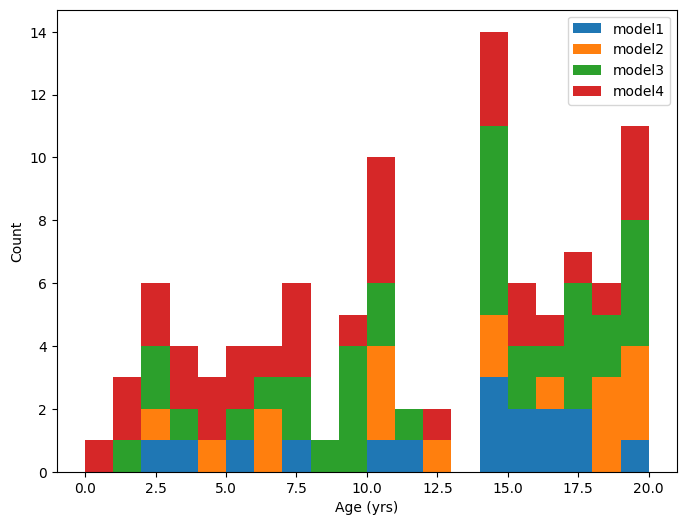

In [7]:
plt.figure(figsize=(8, 6))
_, bins, _ = plt.hist([machines.loc[machines['model'] == 'model1', 'age'],
                       machines.loc[machines['model'] == 'model2', 'age'],
                       machines.loc[machines['model'] == 'model3', 'age'],
                       machines.loc[machines['model'] == 'model4', 'age']],
                       20, stacked=True, label=['model1', 'model2', 'model3', 'model4'])
plt.xlabel('Age (yrs)')
plt.ylabel('Count')
plt.legend()

### Interpretación del gráfico

La figura muestra la distribución de la **antigüedad de las máquinas** agrupada por modelo.

Se observa que el conjunto de datos contiene **cuatro modelos de máquinas** (`model1`, `model2`, `model3` y `model4`), representados mediante diferentes colores. Además, todos los modelos presentan máquinas con distintos años de servicio, lo que proporciona una buena diversidad para el análisis.

La **antigüedad de la máquina** será una variable importante durante el proceso de modelado, ya que es razonable esperar que máquinas con más años de operación presenten patrones de desgaste, errores y fallas diferentes a los de máquinas más recientes.

En el siguiente notebook, esta información se integrará con los datos de telemetría, mantenimiento, errores y fallas para construir el conjunto de datos que será utilizado para entrenar el modelo de mantenimiento predictivo.

## Conjunto de datos de errores

El conjunto de datos **Errors** contiene el registro de los eventos de error detectados durante la operación de las máquinas.

Estos errores **no representan una falla del equipo**, ya que las máquinas continúan operando después de que el evento ocurre. Sin embargo, la aparición de determinados tipos de errores puede ser un indicador temprano del deterioro de un componente y, por tanto, resultar útil para anticipar una futura falla.

Cada registro incluye la siguiente información:

- **Datetime:** Fecha y hora en la que se registró el evento.
- **Machine ID:** Identificador de la máquina donde ocurrió el error.
- **Error ID:** Tipo de error detectado.

> **Nota:** La marca de tiempo (*datetime*) está registrada con una resolución de **una hora**, ya que los datos de telemetría también fueron recolectados con esa misma frecuencia. Esto facilitará la integración de ambos conjuntos de datos durante la etapa de ingeniería de características.

In [8]:
errors = datasets['Errors']
errors.head(10)

,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4
5,2015-01-25 15:00:00,1,error4
6,2015-01-27 04:00:00,1,error1
7,2015-03-03 22:00:00,1,error2
8,2015-03-05 06:00:00,1,error1
9,2015-03-20 18:00:00,1,error1


El siguiente histograma detalla la distribución de los errores registrados en los archivos de registro.

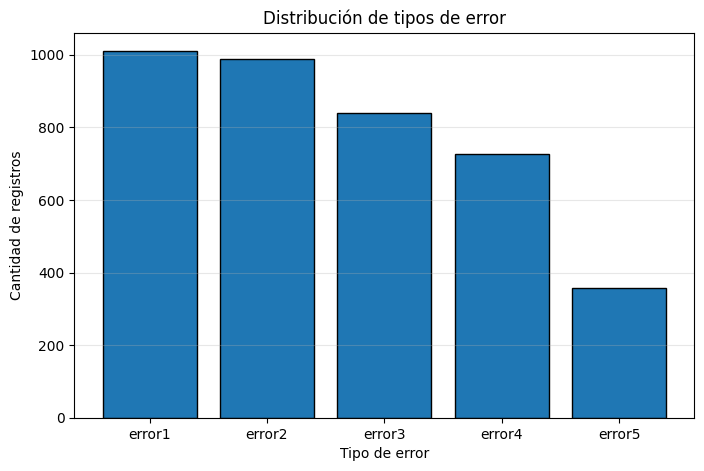

In [9]:
# Cantidad de registros por tipo de error
error_counts = errors["errorID"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    error_counts.index,
    error_counts.values,
    edgecolor="black"
)

plt.title("Distribución de tipos de error")
plt.xlabel("Tipo de error")
plt.ylabel("Cantidad de registros")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretación del gráfico

El conjunto de datos **Errors** registra una serie temporal de eventos de error asociados a cada máquina. Cada registro indica la fecha y hora en que ocurrió el evento, la máquina involucrada y el tipo de error detectado.

La figura muestra la distribución de los eventos registrados para cada uno de los **cinco tipos de error** presentes en el conjunto de datos.

Este análisis exploratorio permite identificar qué tipos de errores ocurren con mayor frecuencia y proporciona una primera aproximación al comportamiento operativo de las máquinas.

En los siguientes notebooks, esta información se combinará con los datos de telemetría, mantenimiento y fallas para identificar patrones que permitan anticipar posibles fallas mediante técnicas de Machine Learning.

## Conjunto de datos de mantenimiento

El conjunto de datos **Maintenance** contiene el historial de las actividades de mantenimiento realizadas sobre las máquinas durante el período de estudio.

Los registros incluyen tanto:

- **Mantenimientos programados:** Actividades preventivas realizadas de forma periódica para inspeccionar o conservar el buen funcionamiento de los equipos.
- **Mantenimientos no programados:** Intervenciones correctivas ocasionadas por el deterioro de un componente o por problemas detectados durante la operación.

Cada registro almacena la siguiente información:

- **Datetime:** Fecha y hora en que se realizó el mantenimiento.
- **Machine ID:** Identificador de la máquina intervenida.
- **Comp:** Componente sobre el cual se realizó la intervención.

En este caso de estudio, el historial de mantenimiento abarca los años **2014 y 2015**. Disponer de información previa al período de análisis permite reconstruir el historial de intervenciones de cada máquina y estimar el tiempo transcurrido desde el último mantenimiento de cada componente.

Esta información será utilizada en el siguiente notebook para generar variables relacionadas con el historial de mantenimiento, las cuales pueden mejorar la capacidad predictiva del modelo.


In [10]:
# lectura con Pandas
maint =datasets['Maintenance']
maint.head()

,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4


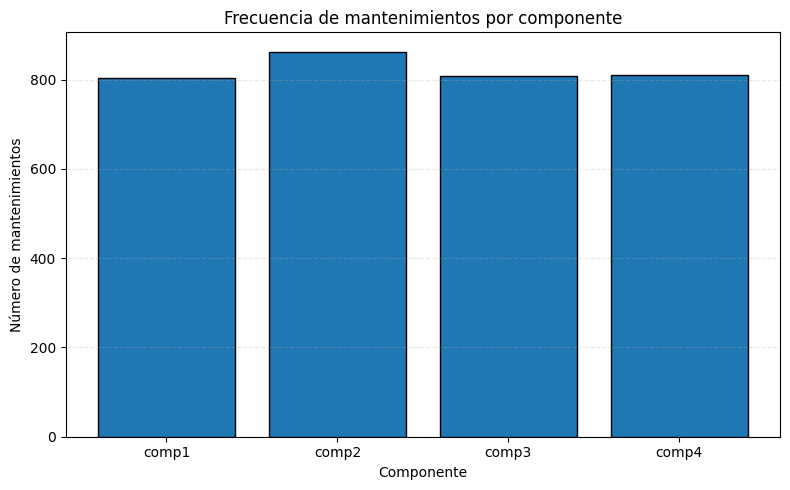

In [11]:
# Conteo de mantenimientos por componente
comp_counts = maint["comp"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    comp_counts.index,
    comp_counts.values,
    edgecolor="black"
)

plt.title("Frecuencia de mantenimientos por componente")
plt.xlabel("Componente")
plt.ylabel("Número de mantenimientos")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación del gráfico

La figura muestra la frecuencia de las actividades de mantenimiento registradas para cada uno de los cuatro componentes de las máquinas.

Se observa que las intervenciones se distribuyen de manera relativamente uniforme entre los componentes, aunque **`comp2` presenta una frecuencia de mantenimiento ligeramente superior** a la de los demás.

Esta distribución sugiere que todos los componentes requieren actividades de mantenimiento con una periodicidad similar, lo que proporciona un historial equilibrado para el análisis.

En el siguiente notebook aprovecharemos esta información para construir nuevas variables, como el tiempo transcurrido desde el último mantenimiento y la frecuencia de intervenciones por componente, las cuales podrán aportar información relevante para el entrenamiento del modelo de mantenimiento predictivo.

## Conjunto de datos de telemetría

El conjunto de datos **Telemetry** contiene las mediciones registradas por los sensores instalados en cada una de las máquinas durante su operación.

Cada registro representa el estado operativo de una máquina en un instante determinado e incluye las siguientes variables:

- **Datetime:** Fecha y hora de la medición.
- **Machine ID:** Identificador de la máquina.
- **Volt:** Voltaje registrado por el equipo.
- **Rotate:** Velocidad de rotación del eje (rpm).
- **Pressure:** Presión medida por el sensor.
- **Vibration:** Nivel de vibración de la máquina.

Las mediciones fueron registradas con una frecuencia **horaria**, por lo que cada fila representa el comportamiento de una máquina durante una hora específica de operación.

Este conjunto de datos constituye la principal fuente de información para el desarrollo del modelo de mantenimiento predictivo, ya que refleja las condiciones reales de funcionamiento de las máquinas y permite identificar cambios en su comportamiento que podrían anticipar una futura falla.


In [12]:
# Leer el conjunto de datos en un DataFrame de Pandas
telemetry = datasets["Telemetry"]

# Manejar valores faltantes

# Definir grupos de variables
features_datetime = ['datetime']
features_categorical = ['machineID']
features_numeric = list(set(telemetry.columns) - set(features_datetime) - set(features_categorical))

# Reemplazar los valores faltantes de las variables numéricas por 0
telemetry[features_numeric] = telemetry[features_numeric].fillna(0)

# Reemplazar los valores faltantes de las variables categóricas por "Unknown"
telemetry[features_categorical] = telemetry[features_categorical].fillna("Unknown")

# Mostrar el número de registros por columna
print(telemetry.count())

# Visualizar las primeras 10 filas del conjunto de datos
telemetry.head(10)

datetime     876100
machineID    876100
volt         876100
rotate       876100
pressure     876100
vibration    876100
dtype: int64


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511
5,2015-01-01 11:00:00,1,172.504839,430.323362,95.927042,35.655017
6,2015-01-01 12:00:00,1,156.556031,499.071623,111.755684,42.753920
7,2015-01-01 13:00:00,1,172.522781,409.624717,101.001083,35.482009
8,2015-01-01 14:00:00,1,175.324524,398.648781,110.624361,45.482287
9,2015-01-01 15:00:00,1,169.218423,460.850670,104.848230,39.901735


## Visualización temporal de la telemetría

Para comprender el comportamiento de los sensores, analizaremos las mediciones de una máquina específica durante un intervalo de tiempo.

En este ejemplo se selecciona la **máquina 1** y se visualizan las variables de telemetría registradas durante el mes de febrero de 2015.

In [13]:
# ==========================================================
# Telemetría de una máquina específica
# ==========================================================

# Seleccionar una máquina
plot_data = telemetry[telemetry["machineID"] == 1].copy()

# Convertir la fecha a formato datetime
plot_data["datetime"] = pd.to_datetime(plot_data["datetime"])

# Filtrar un intervalo de tiempo
plot_data = plot_data[
    (plot_data["datetime"] >= "2015-02-01") &
    (plot_data["datetime"] <= "2015-03-01")
]

plot_data.head()

,datetime,machineID,volt,rotate,pressure,vibration
738,2015-02-01 00:00:00,1,161.366805,354.403540,87.529260,40.679471
739,2015-02-01 01:00:00,1,168.840187,501.326976,95.896965,39.724321
740,2015-02-01 02:00:00,1,145.581202,425.328660,101.703525,44.824130
741,2015-02-01 03:00:00,1,171.948847,430.039942,112.137024,36.585952
742,2015-02-01 04:00:00,1,163.614903,441.758062,106.058170,40.252144


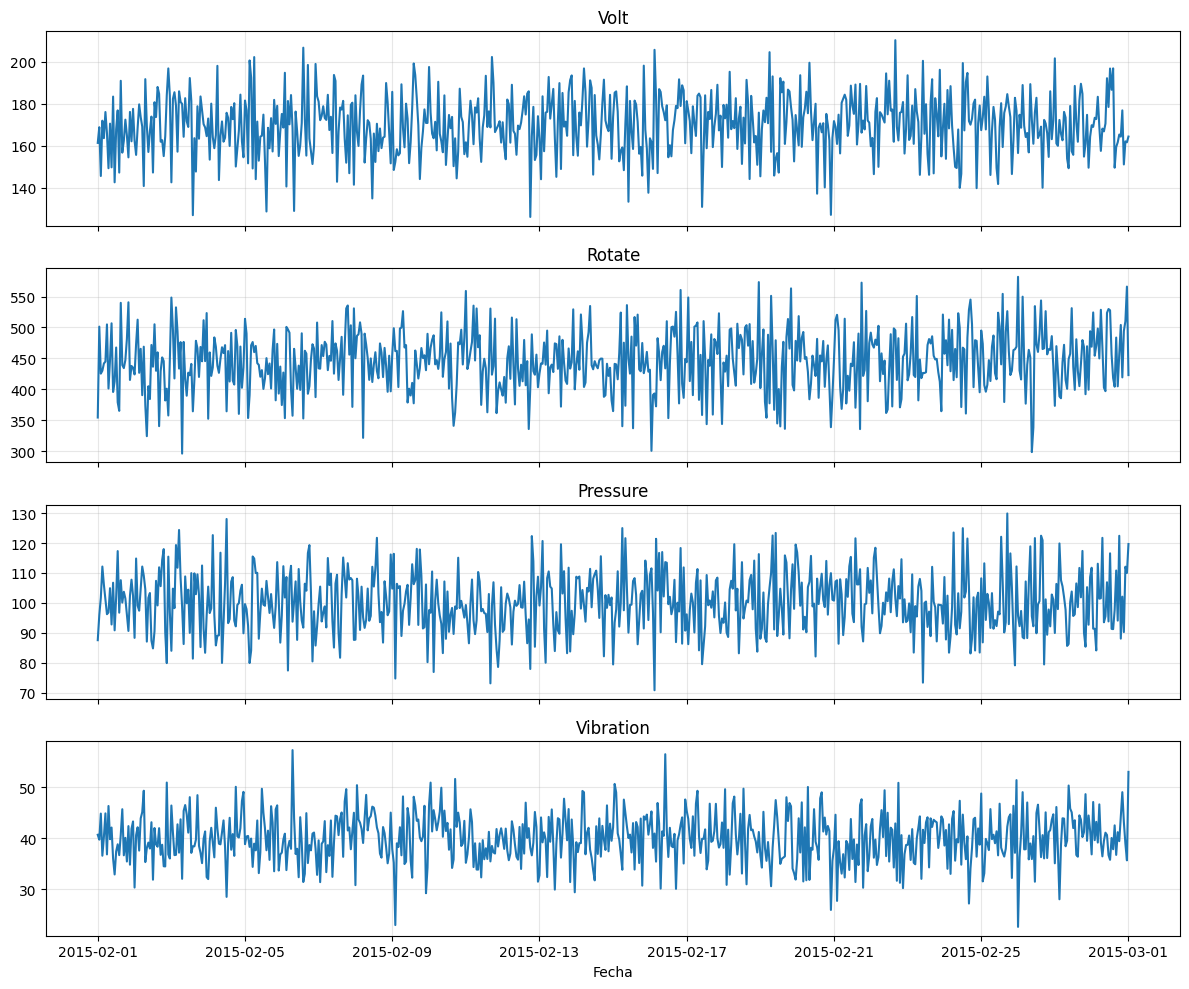

In [14]:
# ==========================================================
# Variables de telemetría en el tiempo
# ==========================================================

variables = ["volt", "rotate", "pressure", "vibration"]

fig, axes = plt.subplots(
    len(variables),
    1,
    figsize=(12,10),
    sharex=True
)

for ax, variable in zip(axes, variables):

    ax.plot(
        plot_data["datetime"],
        plot_data[variable],
        linewidth=1.5
    )

    ax.set_title(variable.capitalize())
    ax.grid(alpha=0.3)

plt.xlabel("Fecha")

plt.tight_layout()

plt.show()

### Interpretación del gráfico

La figura muestra la evolución de las **cuatro variables de telemetría** registradas para una máquina durante un período aproximado de un mes.

Cada panel corresponde a una variable diferente:

- **Volt:** Voltaje medido por los sensores.
- **Rotate:** Velocidad de rotación del eje.
- **Pressure:** Presión registrada durante la operación.
- **Vibration:** Nivel de vibración de la máquina.

Se observa que las variables presentan fluctuaciones naturales a lo largo del tiempo, propias de las condiciones normales de operación del equipo. No obstante, también pueden apreciarse cambios puntuales y variaciones más pronunciadas en algunos intervalos, las cuales podrían estar asociadas con cambios en el estado de la máquina.

En el siguiente notebook, estas señales temporales serán utilizadas para construir nuevas características, como promedios móviles, desviaciones estándar y tendencias, que permitirán capturar el comportamiento dinámico de las máquinas y mejorar el desempeño del modelo de mantenimiento predictivo.


## Conjunto de datos de fallas

El conjunto de datos **Failures** registra las fallas ocurridas en las máquinas durante el período de estudio.

Cada registro corresponde al reemplazo de un componente como consecuencia de una falla e incluye la siguiente información:

- **Datetime:** Fecha y hora en la que ocurrió la falla.
- **Machine ID:** Identificador de la máquina afectada.
- **Failure:** Componente que presentó la falla y fue reemplazado.

A diferencia del conjunto de datos **Errors**, que almacena eventos de advertencia durante la operación normal, este conjunto representa las **fallas reales** que requirieron la sustitución de un componente.

Esta información será fundamental en las siguientes etapas del laboratorio, ya que permitirá construir la **variable objetivo** (*target*) que utilizarán los modelos de Machine Learning para aprender a predecir futuras fallas a partir de la información de telemetría, mantenimiento y errores.

In [15]:
#Lectura con Pandas
failures = datasets["Failures"]

print(failures.count())
failures.head()

datetime     761
machineID    761
failure      761
dtype: int64


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4


El siguiente histograma detalla la distribución de los registros de fallos obtenidos a partir del registro de fallos. Este registro se elaboró ​​originalmente a partir de las sustituciones de componentes que figuraban en el archivo de registro de mantenimiento.

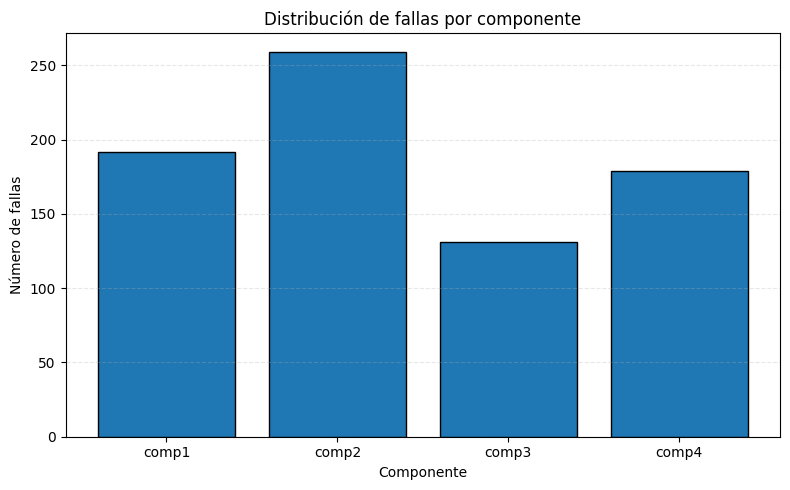

In [16]:
# ==========================================================
# Distribución de fallas por componente
# ==========================================================

failure_counts = failures["failure"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    failure_counts.index,
    failure_counts.values,
    edgecolor="black"
)

plt.title("Distribución de fallas por componente")
plt.xlabel("Componente")
plt.ylabel("Número de fallas")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación del gráfico

La figura muestra la distribución de las fallas registradas para cada uno de los cuatro componentes de las máquinas durante el período de estudio.

Se observa que las fallas no se presentan con la misma frecuencia en todos los componentes. El componente **`comp2`** registra el mayor número de fallas, mientras que **`comp3`** presenta la menor cantidad. Por su parte, **`comp1`** y **`comp4`** muestran un comportamiento intermedio.

Esta distribución sugiere que algunos componentes son más propensos a fallar que otros, información que resulta de gran utilidad para el desarrollo de estrategias de mantenimiento predictivo.

En el siguiente notebook, estos registros de fallas se combinarán con la información de telemetría, errores y mantenimiento para construir la **variable objetivo** que permitirá entrenar el modelo de Machine Learning encargado de predecir futuras fallas.

# Conclusiones

En este primer laboratorio realizamos la etapa de **ingesta y exploración de datos** del caso de estudio de mantenimiento predictivo.

Durante el desarrollo del notebook:

- Cargamos los cinco conjuntos de datos del proyecto utilizando **Pandas**.
- Exploramos la estructura y el contenido de cada fuente de información.
- Verificamos los tipos de datos, los valores faltantes y los registros duplicados.
- Analizamos mediante visualizaciones las características de las máquinas, los registros de errores, las actividades de mantenimiento, las señales de telemetría y el historial de fallas.
- Comprendimos el propósito de cada conjunto de datos y su papel dentro del proceso de mantenimiento predictivo.

Al finalizar este notebook contamos con una comprensión clara de la información disponible y de la relación existente entre las diferentes fuentes de datos.

En el siguiente laboratorio, **Notebook 2 – Ingeniería de características**, integraremos estos cinco conjuntos de datos para construir un único conjunto de entrenamiento, generando nuevas variables que capturen el comportamiento histórico y operativo de las máquinas y que servirán como entrada para el modelo de Machine Learning.
